# TRABAJO UT6 - CLASIFICACIÓN

Voy a usar el dataset **Breast Cancer** de sklearn, que es el que trabajamos en clase en el notebook 3. Tiene 569 muestras de tumores mamarios con 30 características cada una y una variable target que indica si es maligno (0) o benigno (1).

---
## 1. Preprocesado de los datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Importar dataset

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

# Lo meto en un dataframe para verlo mejor
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
# Veo cómo están repartidas las clases
print(df['target'].value_counts())
print()
print("0 = Maligno")
print("1 = Benigno")

target
1    357
0    212
Name: count, dtype: int64

0 = Maligno
1 = Benigno


Tenemos 569 muestras con 30 features numéricas. Hay 212 malignos y 357 benignos, o sea que hay un poco más de benignos pero tampoco está muy desbalanceado.

### Manejar datos missing

In [6]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

No hay ningún valor nulo. Si los hubiese se podrían tratar con `SimpleImputer` (rellenando con la media o mediana) o eliminando filas con `dropna()`.

### Manejar datos categóricos

En este caso todas las columnas son float64, no hay ninguna variable categórica. Pero si las hubiese, las técnicas que vimos son:

- **Label Encoding**: asignar un número a cada categoría (rojo=0, verde=1, azul=2). Problema: el modelo puede pensar que hay un orden.
- **Ordinal Encoding**: lo mismo pero cuando sí hay orden (bajo=0, medio=1, alto=2).
- **One-Hot Encoding**: crear una columna binaria por cada categoría. Se hace con `pd.get_dummies()` o `OneHotEncoder`.
- **Variables dummy**: como one-hot pero eliminando una columna para evitar la trampa de las variables dummy.

In [7]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

Todo numérico, no necesitamos codificar nada.

### Trampa de las variables dummy

Cuando hacemos one-hot encoding y dejamos todas las columnas, se produce multicolinealidad perfecta (una columna se puede deducir de las otras). La solución es eliminar una columna con `drop_first=True` en `pd.get_dummies()`. En nuestro dataset no aplica porque no tenemos categóricas, pero es importante tenerlo en cuenta.

In [8]:
# Ejemplo: si tuviéramos una columna 'color' con rojo, verde, azul
# pd.get_dummies(df, columns=['color'], drop_first=True)
# Eso crearía solo color_verde y color_azul (si ambas son 0, es rojo)
print("No aplica en este dataset")

No aplica en este dataset


### Separar en train y test

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train:

 (426, 30)
Test: (143, 30)


### Estandarizar los datos

Es necesario escalar porque si no, las variables con valores grandes (como area) dominarían sobre las que tienen valores pequeños. Usamos `StandardScaler` que deja media 0 y desviación típica 1. Importante hacer `fit_transform` solo en train y luego `transform` en test para no hacer data leakage.

In [10]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

print(X_train_sc[:3])

[[-0.65079907 -0.43057322 -0.68024847 -0.62698309 -0.91381897 -0.93335153
  -0.78763077 -0.67944444  0.25404078 -0.79877182 -0.68958948  0.04723809
  -0.78036299 -0.55337361  0.21546423 -0.59450332 -0.55964264 -0.52889336
  -0.30718648 -0.73414209 -0.6661438   0.01849243 -0.68117939 -0.63150142
   0.19196229 -0.50775064 -0.69592933 -0.36433881  0.32349851 -0.7578486 ]
 [-0.82835341  0.15226547 -0.82773762 -0.75309358  0.65281216 -0.70875266
  -1.06654609 -1.07190884  0.48903741 -0.34145374 -0.37372313  1.38156616
  -0.42829675 -0.43492182  2.09091025 -0.82810471 -0.90419591 -1.14032681
   2.68441903 -0.66600912 -0.88704517  0.02344492 -0.90048554 -0.77100112
   0.43210093 -1.02916891 -1.29277423 -1.45036679  0.62563098 -1.03071387]
 [ 1.68277234  2.18977235  1.60009756  1.67383892  0.10362413 -0.0053256
   0.70576603  1.25773115 -0.19064516 -1.06468841  1.25755573  2.29250167
   1.14701755  1.2040052  -0.43129014 -0.05002332  0.24833683  0.85991228
  -0.17780656 -0.46237147  1.50809835

---
## 2. EDA básico

Siguiendo la estructura del Colab 5.4, vamos a hacer un análisis exploratorio con pairplot, mapa de calor de correlaciones y luego limpiar columnas que no aporten.

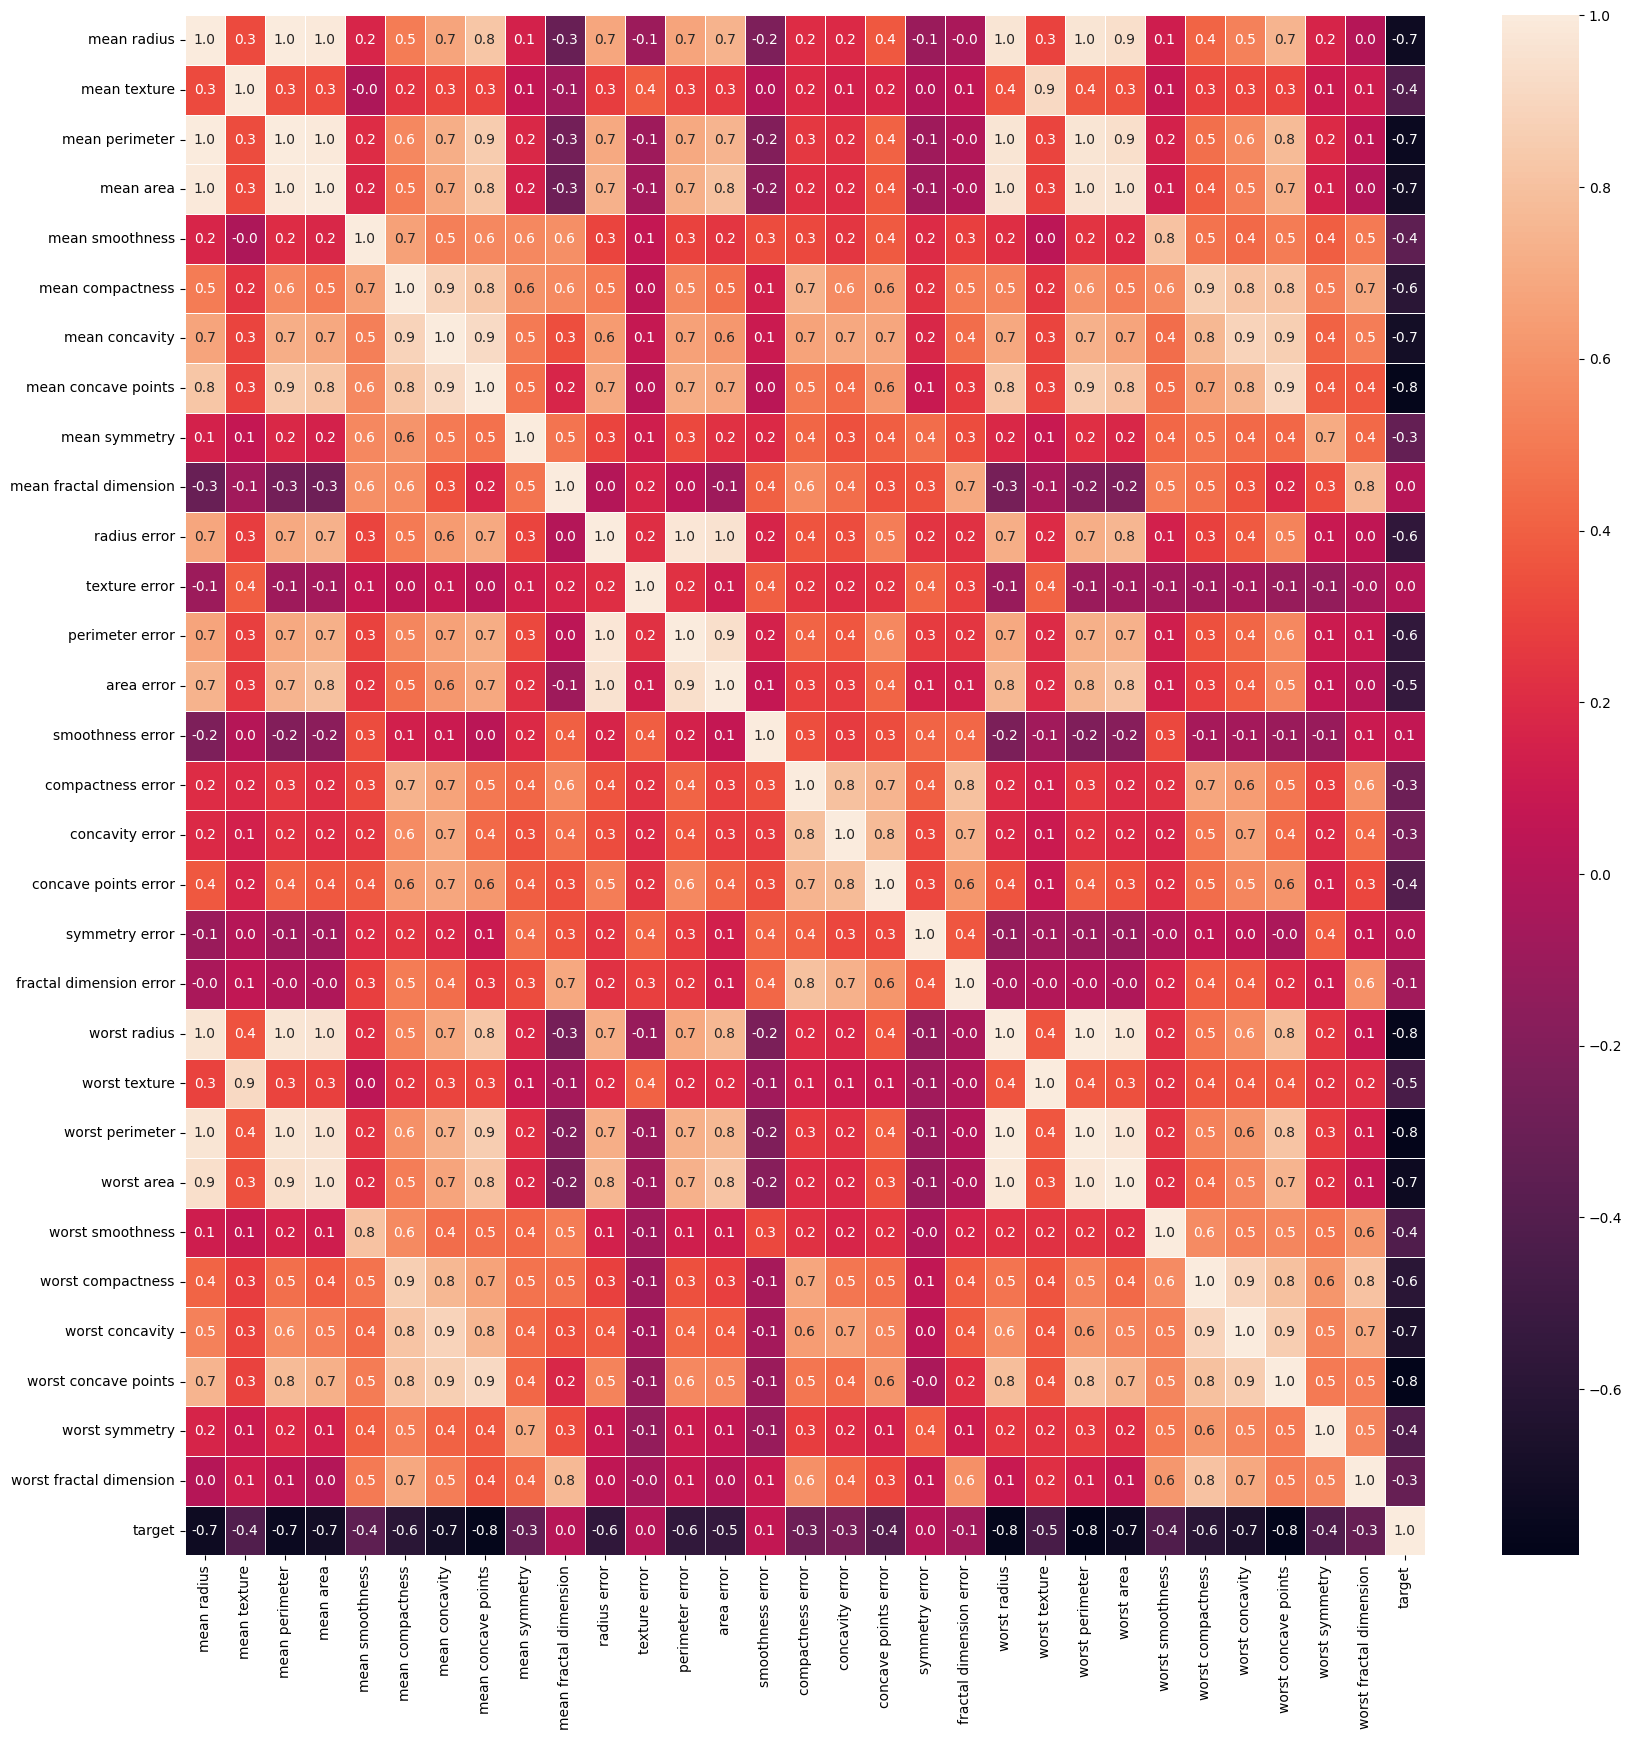

In [11]:
# Mapa de calor de correlaciones (como en el colab)
f, ax = plt.subplots(figsize=(20, 20))
g = sns.heatmap(df.corr(), annot=True, linewidths=0.4, fmt='.1f', ax=ax)
plt.show()

Se ve que hay muchas variables con correlación muy alta entre sí. Por ejemplo radius_mean, perimeter_mean y area_mean están muy correlacionadas (>0.9), lo cual tiene sentido porque las tres miden cosas relacionadas con el tamaño.

In [12]:
# Correlaciones con el target
corr_target = df.corr()['target'].sort_values()
print(corr_target)

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

Las variables con correlación negativa más fuerte con target (las más útiles para identificar malignos) son worst perimeter, worst concave points, worst radius, mean concave points...

Top 5: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter']


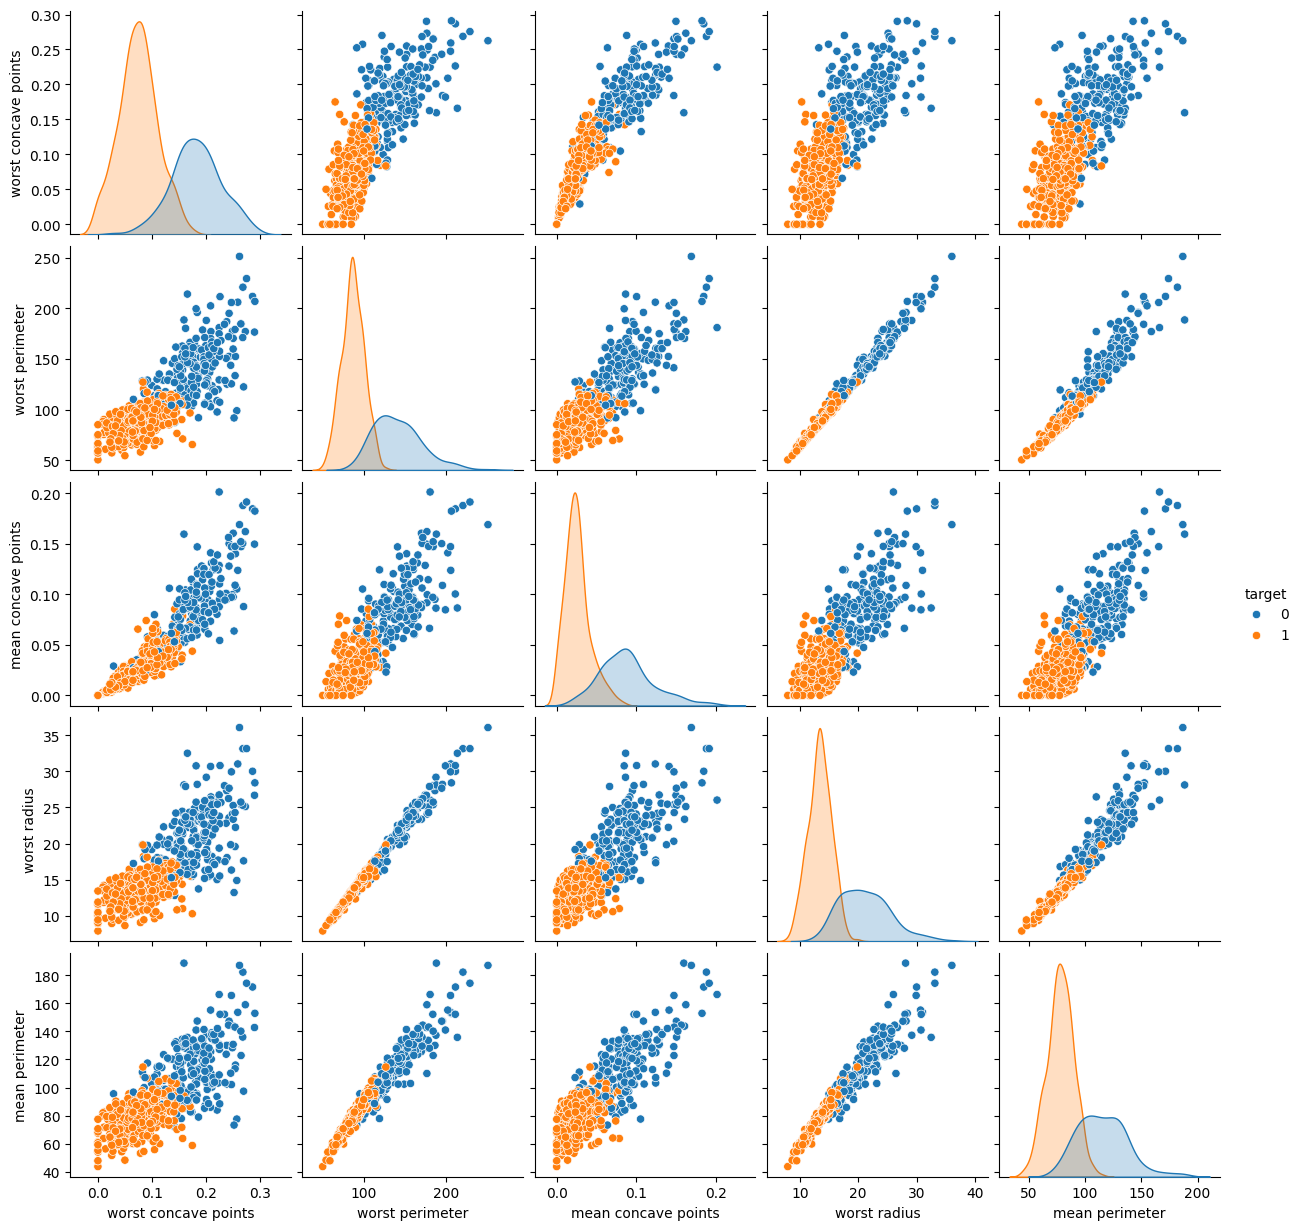

In [13]:
# Pairplot con las 5 variables que más correlacionan con target
# No lo hago con las 30 porque tardaría una eternidad
top5 = corr_target.abs().sort_values(ascending=False).drop('target').head(5).index.tolist()
print("Top 5:", top5)

sns.pairplot(df[top5 + ['target']], hue='target')
plt.show()

En el pairplot se ve bastante bien cómo se separan las dos clases. Los tumores malignos (0, en azul) tienden a tener valores más altos en worst perimeter, worst concave points, etc.

### Limpiar columnas correlacionadas

Vamos a quitar las columnas que tengan correlación > 0.9 entre sí, porque son redundantes y no aportan información nueva.

In [14]:
corr_matrix = df.drop('target', axis=1).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print(f"Columnas a eliminar ({len(to_drop)}): {to_drop}")

Columnas a eliminar (10): ['mean perimeter', 'mean area', 'mean concave points', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']


In [15]:
df_clean = df.drop(columns=to_drop)
print(f"Antes: {df.shape[1]} columnas")
print(f"Después: {df_clean.shape[1]} columnas")

Antes: 31 columnas
Después: 21 columnas


In [16]:
# Rehago el split con los datos limpios
X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# Guardo los nombres de las columnas para después
feature_names = X.columns

print("Train:", X_train_sc.shape)
print("Test:", X_test_sc.shape)

Train: (426, 20)
Test: (143, 20)


### Conclusiones del EDA

- No hay nulos ni categóricos.
- Muchas variables miden cosas parecidas y están correlacionadas >0.9, así que las he eliminado.
- Las features más relevantes para distinguir maligno/benigno son las de tipo "worst" (peor valor del tumor).
- Tras limpiar nos quedamos con un dataset más reducido y sin redundancias.

---
## 3. Regresión Logística

Aunque se llama "regresión", en realidad se usa para clasificación binaria. Utiliza la función sigmoide para convertir una combinación lineal de las features en una probabilidad entre 0 y 1. Si P > 0.5 predice clase 1, si no clase 0.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression(random_state=0, max_iter=10000)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, lr.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_lr), 4))
print()
print(confusion_matrix(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr, target_names=['Maligno', 'Benigno']))

Accuracy train: 0.9836
Accuracy test: 0.958

[[49  4]
 [ 2 88]]

              precision    recall  f1-score   support

     Maligno       0.96      0.92      0.94        53
     Benigno       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



---
## 4. K-Vecinos Cercanos (KNN)

KNN no entrena un modelo como tal, sino que guarda todos los datos y cuando llega uno nuevo mira cuáles son sus K vecinos más cercanos y le asigna la clase mayoritaria. Es lo que llaman un "lazy learner". Usamos la distancia de Minkowski con p=2 que es la euclídea, como vimos en clase.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, knn.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_knn), 4))
print()
print(confusion_matrix(y_test, y_pred_knn))
print()
print(classification_report(y_test, y_pred_knn, target_names=['Maligno', 'Benigno']))

Accuracy train: 0.9695
Accuracy test: 0.9371

[[48  5]
 [ 4 86]]

              precision    recall  f1-score   support

     Maligno       0.92      0.91      0.91        53
     Benigno       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



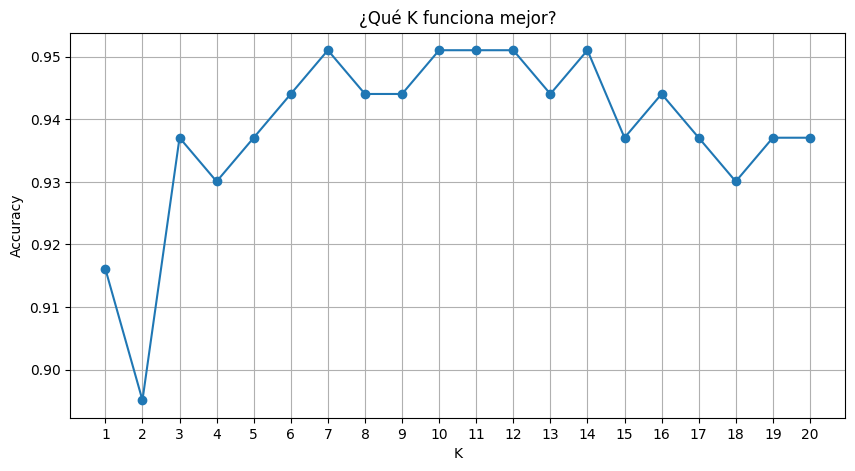

Mejor K = 7 con accuracy 0.9510


In [19]:
# Vamos a ver qué K funciona mejor
acc_por_k = []
for k in range(1, 21):
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    knn_temp.fit(X_train_sc, y_train)
    acc_por_k.append(accuracy_score(y_test, knn_temp.predict(X_test_sc)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), acc_por_k, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('¿Qué K funciona mejor?')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

print(f"Mejor K = {np.argmax(acc_por_k)+1} con accuracy {max(acc_por_k):.4f}")

---
## 5. Máquinas de Soporte Vectorial (SVM)

SVM busca el hiperplano que separa las clases con el mayor margen posible. El parámetro C controla cuánto penalizamos los errores: C alto = más estricto (riesgo de overfitting), C bajo = más permisivo (más generalización). Vimos esto en los apuntes de Regularización.

### Kernel lineal

In [20]:
from sklearn.svm import SVC

svc_lin = SVC(kernel='linear', probability=True, random_state=0)
svc_lin.fit(X_train_sc, y_train)

y_pred_svc_lin = svc_lin.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, svc_lin.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_svc_lin), 4))
print()
print(confusion_matrix(y_test, y_pred_svc_lin))

Accuracy train: 0.9859
Accuracy test: 0.9371

[[48  5]
 [ 4 86]]


### Kernel no lineal (RBF)

RBF es el kernel gaussiano. Proyecta los datos a un espacio de mayor dimensión para encontrar una separación que en el espacio original no sería lineal. El parámetro gamma controla el alcance de cada punto: gamma alto = influencia local (fronteras complejas), gamma bajo = influencia global (fronteras suaves).

In [21]:
svc_rbf = SVC(kernel='rbf', probability=True, random_state=0)
svc_rbf.fit(X_train_sc, y_train)

y_pred_svc_rbf = svc_rbf.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, svc_rbf.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_svc_rbf), 4))
print()
print(confusion_matrix(y_test, y_pred_svc_rbf))

Accuracy train: 0.9812
Accuracy test: 0.972

[[50  3]
 [ 1 89]]


### Comparación y conclusiones SVM

In [22]:
print("Kernel lineal -> Accuracy test:", round(accuracy_score(y_test, y_pred_svc_lin), 4))
print("Kernel RBF    -> Accuracy test:", round(accuracy_score(y_test, y_pred_svc_rbf), 4))

Kernel lineal -> Accuracy test: 0.9371
Kernel RBF    -> Accuracy test: 0.972


En este caso ambos kernels dan resultados parecidos. Esto tiene sentido porque al ver el pairplot ya se veía que las clases se separan bastante bien de forma lineal. Cuando los datos son linealmente separables, no se gana mucho usando un kernel no lineal, y además el lineal es más rápido.

---
## 6. Naive Bayes

Se basa en el teorema de Bayes: P(A|B) = P(B|A) * P(A) / P(B). La "ingenuidad" es que asume que todas las variables son independientes entre sí, cosa que en la realidad casi nunca se cumple. Aun así suele dar buenos resultados. Usamos GaussianNB porque las features son continuas.

In [23]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_sc, y_train)

y_pred_nb = nb.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, nb.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_nb), 4))
print()
print(confusion_matrix(y_test, y_pred_nb))
print()
print(classification_report(y_test, y_pred_nb, target_names=['Maligno', 'Benigno']))

Accuracy train: 0.9272
Accuracy test: 0.8881

[[46  7]
 [ 9 81]]

              precision    recall  f1-score   support

     Maligno       0.84      0.87      0.85        53
     Benigno       0.92      0.90      0.91        90

    accuracy                           0.89       143
   macro avg       0.88      0.88      0.88       143
weighted avg       0.89      0.89      0.89       143



---
## 7. Árboles de Decisión

Funcionan como un diagrama de preguntas: "¿Es X < 50?" -> Sí/No -> siguiente pregunta... hasta llegar a una hoja con la clase. Para decidir qué pregunta hacer en cada nodo se usa la **entropía** (mide el desorden, 0=puro, 1=máximo caos) y la **ganancia de información** (cuánto se reduce la entropía al hacer un corte). También se puede usar el índice Gini.

Uso `criterion='entropy'` que es lo que se usaba en los notebooks de clase.

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X_train_sc, y_train)

y_pred_tree = tree.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, tree.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_tree), 4))
print()
print(confusion_matrix(y_test, y_pred_tree))
print()
print(classification_report(y_test, y_pred_tree, target_names=['Maligno', 'Benigno']))

Accuracy train: 1.0
Accuracy test: 0.9371

[[49  4]
 [ 5 85]]

              precision    recall  f1-score   support

     Maligno       0.91      0.92      0.92        53
     Benigno       0.96      0.94      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



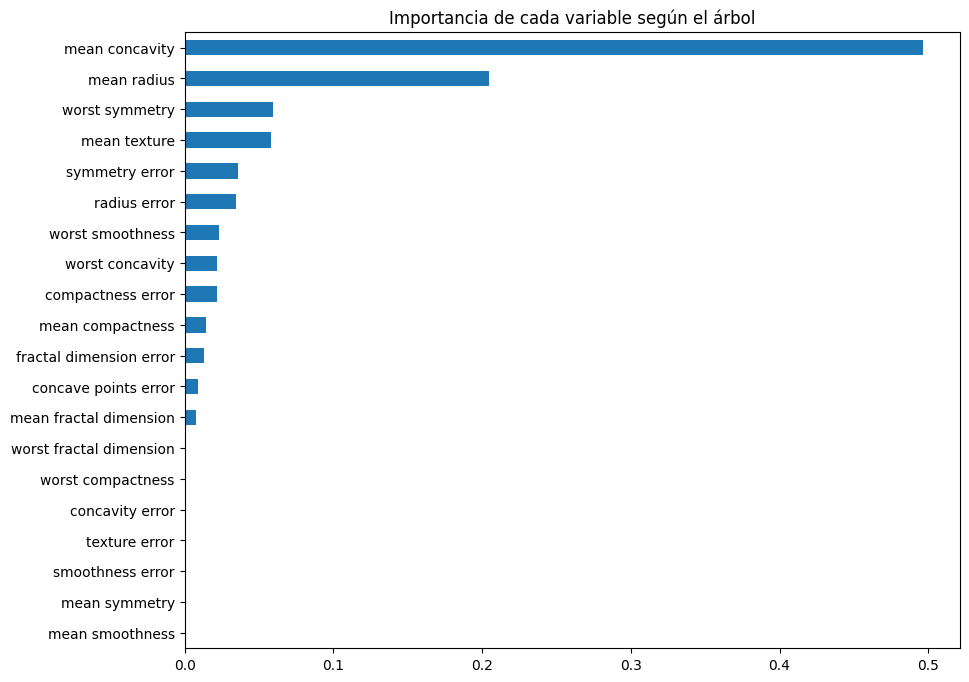

In [25]:
# ¿Qué variables considera más importantes el árbol?
feat_imp = pd.Series(tree.feature_importances_, index=feature_names).sort_values()
feat_imp.plot(kind='barh', figsize=(10, 8))
plt.title('Importancia de cada variable según el árbol')
plt.show()

Ojo que el accuracy en train es 1.0, eso ya nos indica que probablemente está haciendo overfitting (se ha aprendido los datos de memoria). Lo analizamos luego en la evaluación.

---
## 8. Bosques Aleatorios (Random Forest)

Es un ensemble de muchos árboles de decisión. Cada árbol se entrena con un subconjunto aleatorio de datos y features, y luego la predicción final sale por votación mayoritaria. Esto reduce bastante el overfitting que tiene un árbol solo.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)

print("Accuracy train:", round(accuracy_score(y_train, rf.predict(X_train_sc)), 4))
print("Accuracy test:", round(accuracy_score(y_test, y_pred_rf), 4))
print()
print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf, target_names=['Maligno', 'Benigno']))

Accuracy train: 1.0
Accuracy test: 0.9231

[[47  6]
 [ 5 85]]

              precision    recall  f1-score   support

     Maligno       0.90      0.89      0.90        53
     Benigno       0.93      0.94      0.94        90

    accuracy                           0.92       143
   macro avg       0.92      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



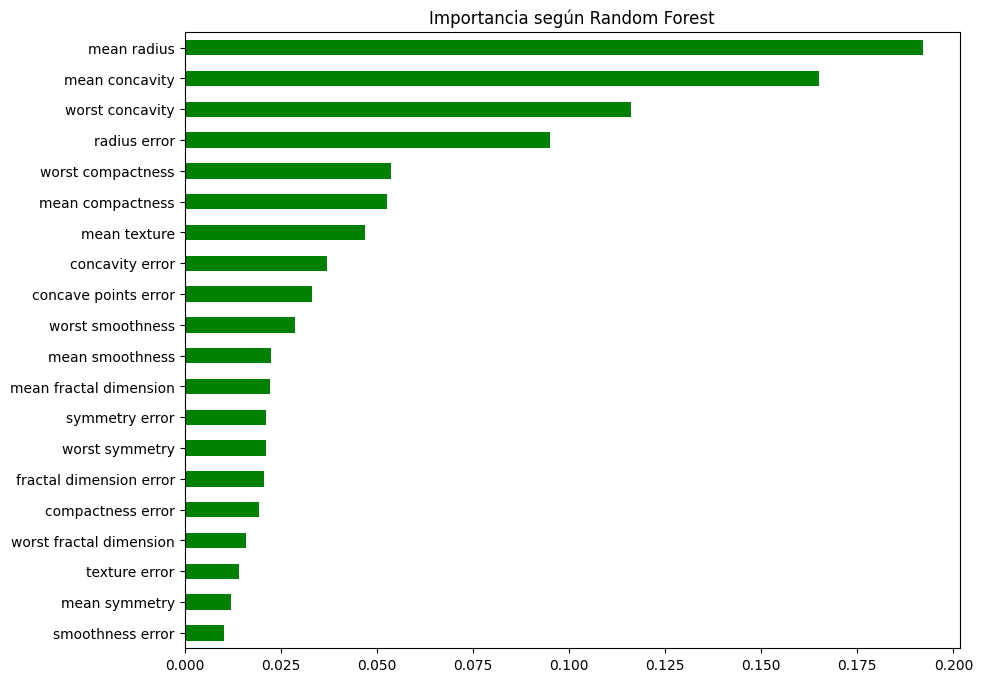

In [27]:
# Importancia de features según el bosque
feat_imp_rf = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
feat_imp_rf.plot(kind='barh', figsize=(10, 8), color='green')
plt.title('Importancia según Random Forest')
plt.show()

---
## 9. Evaluación de los modelos

### Overfitting

Hay overfitting cuando el modelo funciona muy bien en train pero bastante peor en test. Eso quiere decir que se ha aprendido de memoria los datos de entrenamiento en vez de aprender patrones generales. Lo vemos comparando accuracy en train vs test:

In [28]:
modelos = {
    'Reg. Logística': (lr, y_pred_lr),
    'KNN': (knn, y_pred_knn),
    'SVM Lineal': (svc_lin, y_pred_svc_lin),
    'SVM RBF': (svc_rbf, y_pred_svc_rbf),
    'Naive Bayes': (nb, y_pred_nb),
    'Árbol': (tree, y_pred_tree),
    'Random Forest': (rf, y_pred_rf)
}

print(f"{'Modelo':<18} {'Acc Train':>10} {'Acc Test':>10} {'Diferencia':>12}")
print("-"*52)
for nombre, (modelo, y_pred) in modelos.items():
    tr = accuracy_score(y_train, modelo.predict(X_train_sc))
    te = accuracy_score(y_test, y_pred)
    print(f"{nombre:<18} {tr:>10.4f} {te:>10.4f} {tr-te:>12.4f}")

Modelo              Acc Train   Acc Test   Diferencia
----------------------------------------------------
Reg. Logística         0.9836     0.9580       0.0255
KNN                    0.9695     0.9371       0.0324
SVM Lineal             0.9859     0.9371       0.0489
SVM RBF                0.9812     0.9720       0.0092
Naive Bayes            0.9272     0.8881       0.0391
Árbol                  1.0000     0.9371       0.0629
Random Forest          1.0000     0.9231       0.0769


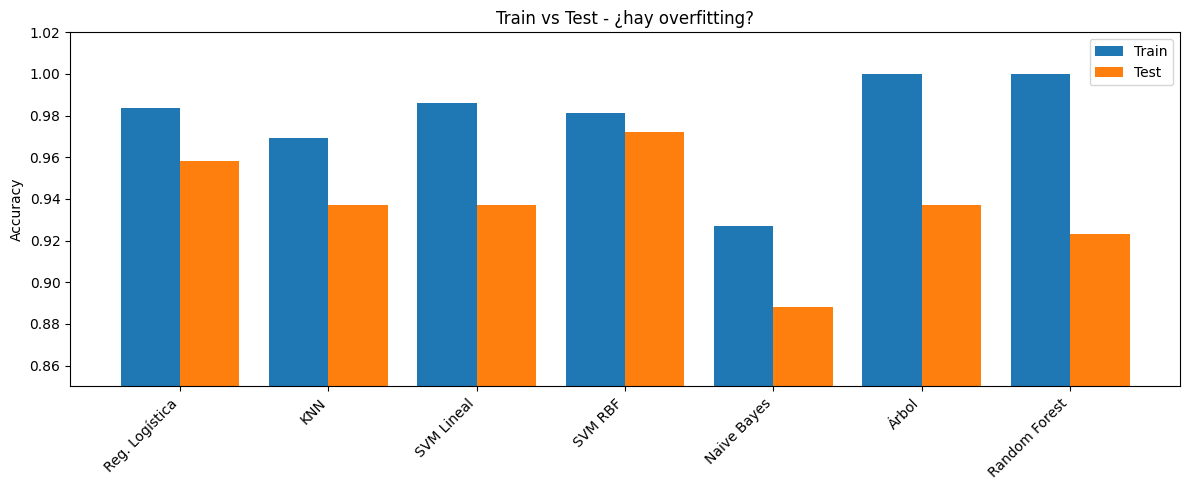

In [29]:
# Lo vemos en un gráfico
nombres = list(modelos.keys())
acc_train = [accuracy_score(y_train, m.predict(X_train_sc)) for m, _ in modelos.values()]
acc_test = [accuracy_score(y_test, yp) for _, yp in modelos.values()]

x = np.arange(len(nombres))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, acc_train, 0.4, label='Train')
ax.bar(x + 0.2, acc_test, 0.4, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.set_title('Train vs Test - ¿hay overfitting?')
plt.tight_layout()
plt.show()

El Árbol de Decisión tiene claramente overfitting: 1.0 en train y bastante menos en test. Se ha memorizado todo. Random Forest también tiene accuracy alto en train pero la caída en test es menor. Los modelos más estables son Regresión Logística y SVM lineal.

### Matriz de confusión y métricas

De la matriz de confusión sacamos:
- **Accuracy** = (TP+TN) / Total
- **Precisión** = TP / (TP+FP) — de los que dije positivos, cuántos acerté
- **Sensitivity (Recall)** = TP / (TP+FN) — de los positivos reales, cuántos pillé
- **Specificity** = TN / (TN+FP) — de los negativos reales, cuántos identifiqué

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

for nombre, (modelo, y_pred) in modelos.items():
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"--- {nombre} ---")
    print(f"  TN={tn}  FP={fp}")
    print(f"  FN={fn}  TP={tp}")
    print(f"  Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precisión:   {precision_score(y_test, y_pred):.4f}")
    print(f"  Sensitivity: {recall_score(y_test, y_pred):.4f}")
    print(f"  Specificity: {tn/(tn+fp):.4f}")
    print(f"  F1:          {f1_score(y_test, y_pred):.4f}")
    print()

--- Reg. Logística ---
  TN=49  FP=4
  FN=2  TP=88
  Accuracy:    0.9580
  Precisión:   0.9565
  Sensitivity: 0.9778
  Specificity: 0.9245
  F1:          0.9670

--- KNN ---
  TN=48  FP=5
  FN=4  TP=86
  Accuracy:    0.9371
  Precisión:   0.9451
  Sensitivity: 0.9556
  Specificity: 0.9057
  F1:          0.9503

--- SVM Lineal ---
  TN=48  FP=5
  FN=4  TP=86
  Accuracy:    0.9371
  Precisión:   0.9451
  Sensitivity: 0.9556
  Specificity: 0.9057
  F1:          0.9503

--- SVM RBF ---
  TN=50  FP=3
  FN=1  TP=89
  Accuracy:    0.9720
  Precisión:   0.9674
  Sensitivity: 0.9889
  Specificity: 0.9434
  F1:          0.9780

--- Naive Bayes ---
  TN=46  FP=7
  FN=9  TP=81
  Accuracy:    0.8881
  Precisión:   0.9205
  Sensitivity: 0.9000
  Specificity: 0.8679
  F1:          0.9101

--- Árbol ---
  TN=49  FP=4
  FN=5  TP=85
  Accuracy:    0.9371
  Precisión:   0.9551
  Sensitivity: 0.9444
  Specificity: 0.9245
  F1:          0.9497

--- Random Forest ---
  TN=47  FP=6
  FN=5  TP=85
  Accuracy: 

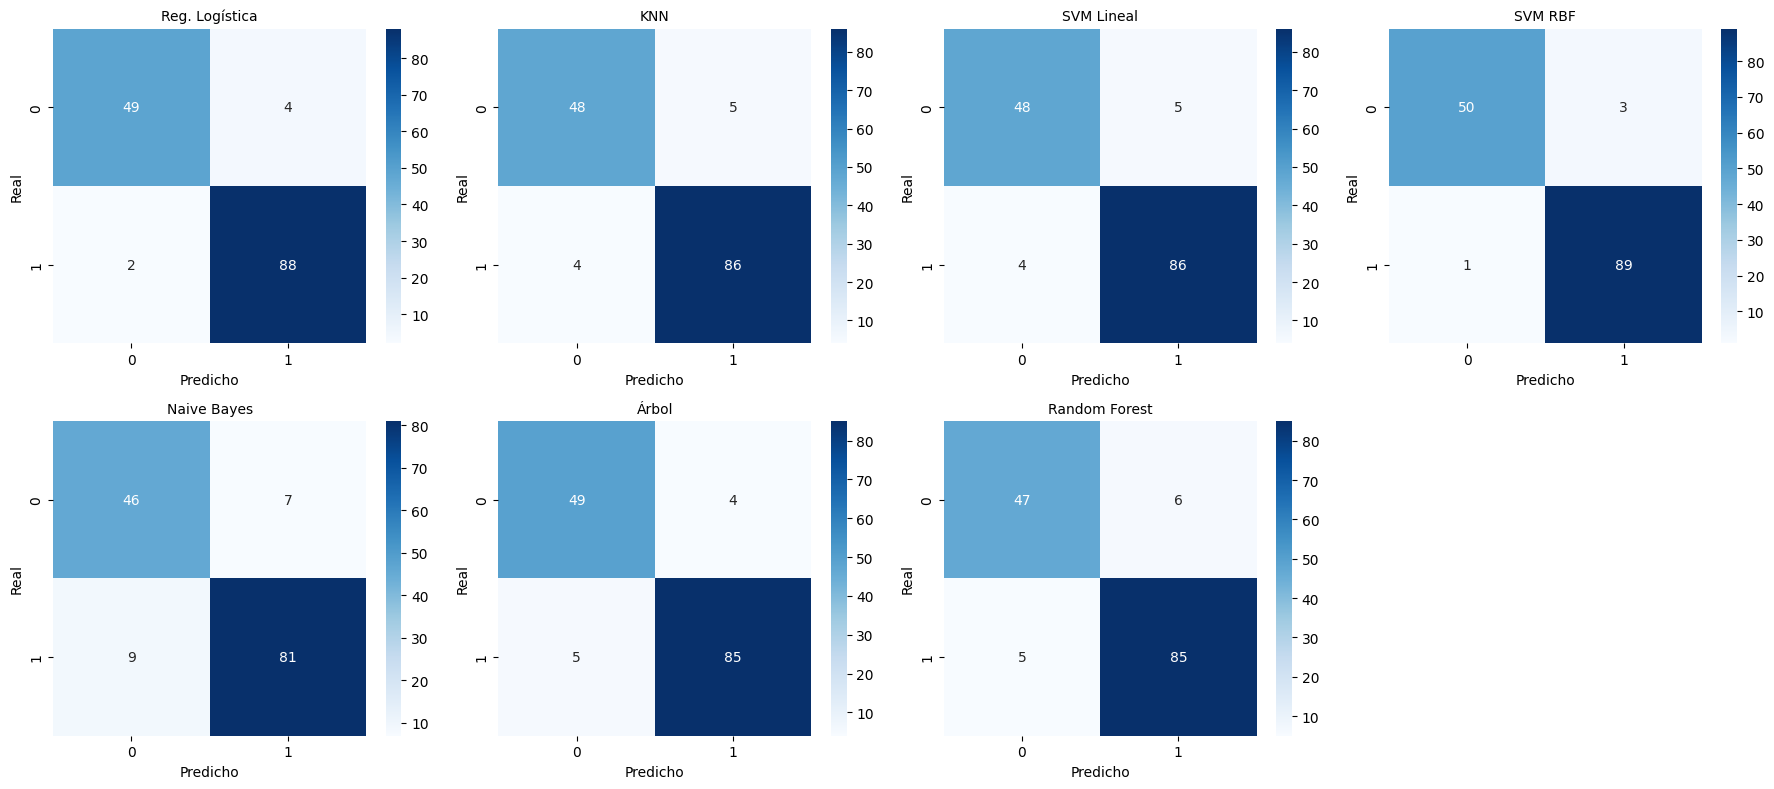

In [31]:
# Matrices de confusión gráficas
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (nombre, (modelo, y_pred)) in enumerate(modelos.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(nombre, fontsize=10)
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Curvas ROC y AUC

La curva ROC representa la tasa de verdaderos positivos (sensitivity) frente a la de falsos positivos (1 - specificity) para distintos umbrales. El AUC es el área bajo esa curva: 1 = perfecto, 0.5 = aleatorio.

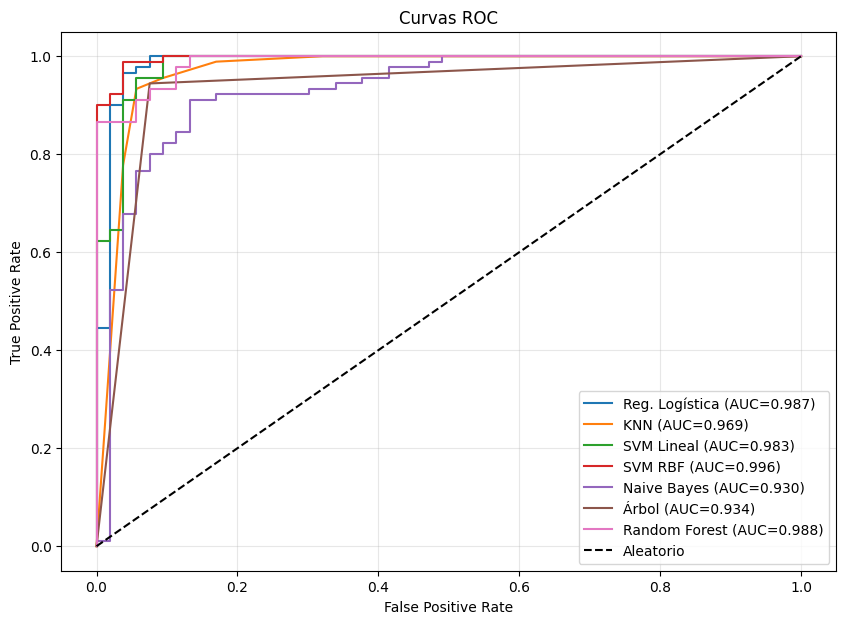

In [32]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for nombre, (modelo, _) in modelos.items():
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Todos los modelos tienen AUC bastante alto (por encima de 0.95), lo que indica que clasifican bien. Las diferencias entre ellos son pequeñas en este dataset.

### Validación cruzada

En vez de depender de una sola partición train/test, la validación cruzada divide los datos en K folds y va rotando cuál es el de test. Así tenemos K medidas de accuracy y podemos ver la media y la variabilidad. Uso 10 folds como en clase.

In [33]:
from sklearn.model_selection import cross_val_score

# Para la CV uso todos los datos escalados
X_all = sc.fit_transform(X)
y_all = y

modelos_cv = {
    'Reg. Logística': LogisticRegression(random_state=0, max_iter=10000),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    'SVM Lineal': SVC(kernel='linear', random_state=0),
    'SVM RBF': SVC(kernel='rbf', random_state=0),
    'Naive Bayes': GaussianNB(),
    'Árbol': DecisionTreeClassifier(criterion='entropy', random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
}

resultados_cv = {}
for nombre, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_all, y_all, scoring='accuracy', cv=10)
    resultados_cv[nombre] = scores
    print(f"{nombre:<18} -> {scores.mean():.4f} (+/- {scores.std():.4f})")

Reg. Logística     -> 0.9719 (+/- 0.0179)
KNN (k=5)          -> 0.9631 (+/- 0.0241)
SVM Lineal         -> 0.9701 (+/- 0.0223)


SVM RBF            -> 0.9701 (+/- 0.0224)
Naive Bayes        -> 0.9016 (+/- 0.0237)
Árbol              -> 0.9263 (+/- 0.0357)


Random Forest      -> 0.9613 (+/- 0.0189)


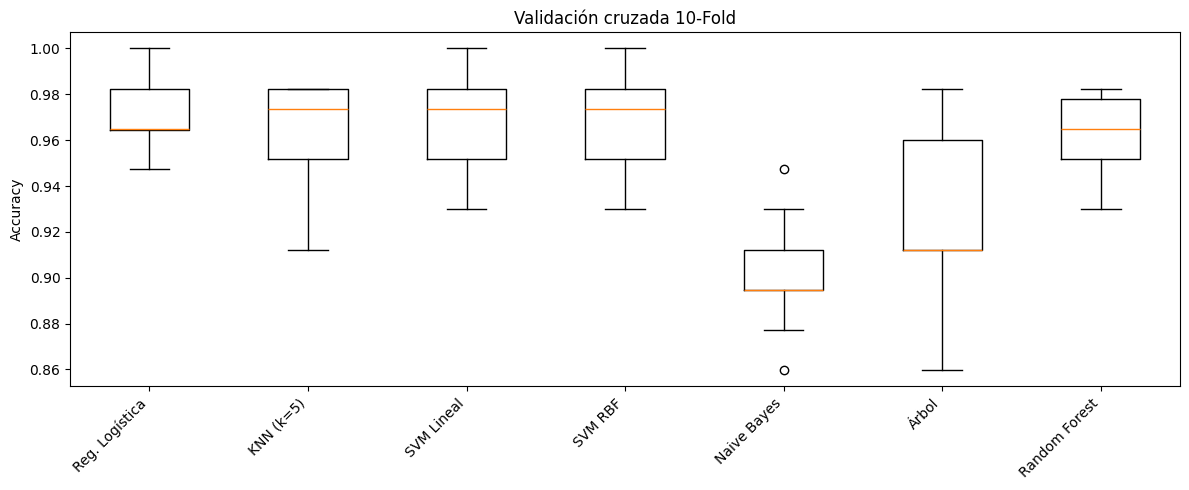

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys())
ax.set_ylabel('Accuracy')
ax.set_title('Validación cruzada 10-Fold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conclusiones de la evaluación

- El **Árbol de Decisión** es el que más overfitting tiene (perfecto en train, peor en test). Sin podar o limitar la profundidad se memoriza los datos.
- **Random Forest** corrige bastante ese problema al promediar muchos árboles.
- Los modelos lineales (**Regresión Logística** y **SVM lineal**) dan resultados muy buenos y estables, lo que indica que los datos son bastante separables linealmente.
- **Naive Bayes** funciona bien a pesar de asumir independencia, que en este dataset no se cumple del todo.
- En medicina, la **sensitivity** es clave porque no queremos fallar en detectar un tumor maligno (un falso negativo puede ser muy grave).
- La validación cruzada confirma que los modelos lineales son los más consistentes.

---
## 10. GridSearch

GridSearchCV prueba de forma exhaustiva todas las combinaciones de hiperparámetros que le digamos para encontrar la mejor. Usa validación cruzada internamente para evaluar cada combinación. Lo hacemos como en el notebook de clase (2_Grid_search).

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

models = {
    'LogisticRegression': LogisticRegression(random_state=0, max_iter=10000),
    'SVM': svm.SVC(random_state=0),
    'RandomForest': RandomForestClassifier(random_state=0),
    'KNN': KNeighborsClassifier()
}

params = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'SVM': {
        'kernel': ['linear', 'rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    },
    'RandomForest': {
        'n_estimators': [10, 50, 100],
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 5, 10]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'metric': ['euclidean', 'manhattan']
    }
}

In [36]:
scores = []

for name in models.keys():
    print(f"Probando {name}...")
    clf = GridSearchCV(models[name], params[name], cv=5, return_train_score=False)
    clf.fit(X_train_sc, y_train)
    scores.append({
        'model': name,
        'best_score': round(clf.best_score_, 4),
        'best_params': clf.best_params_,
        'test_score': round(clf.score(X_test_sc, y_test), 4)
    })
    print(f"  Mejor: {clf.best_score_:.4f} con {clf.best_params_}")
    print()

Probando LogisticRegression...


  Mejor: 0.9812 con {'C': 1, 'solver': 'lbfgs'}

Probando SVM...


  Mejor: 0.9812 con {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Probando RandomForest...


  Mejor: 0.9601 con {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 50}

Probando KNN...


  Mejor: 0.9531 con {'metric': 'euclidean', 'n_neighbors': 5}



In [37]:
df_scores = pd.DataFrame(scores)
df_scores

,model,best_score,best_params,test_score
0,LogisticRegression,0.9812,"{'C': 1, 'solver': 'lbfgs'}",0.9580
1,SVM,0.9812,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.9371
2,RandomForest,0.9601,"{'criterion': 'entropy', 'max_depth': None, 'n...",0.9301
3,KNN,0.9531,"{'metric': 'euclidean', 'n_neighbors': 5}",0.9371


### Conclusiones del GridSearch

- GridSearchCV ha encontrado los mejores hiperparámetros para cada modelo probando todas las combinaciones.
- Se confirma que SVM y Regresión Logística son los que mejor funcionan para este dataset.
- Ajustar los hiperparámetros sí que puede mejorar un poco el rendimiento respecto a los valores por defecto.
- Si el dataset fuera mucho más grande se podría usar `RandomizedSearchCV` para no tener que probar todas las combinaciones y ahorrar tiempo.

---
## Conclusión

He probado 6 algoritmos de clasificación distintos con el dataset de breast cancer. Los que mejor resultado dan son Regresión Logística y SVM (sobre todo lineal), lo que indica que los datos son bastante separables linealmente. El Árbol de Decisión es el peor por overfitting, pero Random Forest lo corrige bien. Naive Bayes funciona sorprendentemente bien a pesar de sus suposiciones. El GridSearch confirma que afinando hiperparámetros se puede mejorar un poco cada modelo.